In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print("✅ All imports successful!")
print(f"TensorFlow version: {tf.__version__}")

✅ All imports successful!
TensorFlow version: 2.21.0


In [ ]:
 #Cell 2 — Paths & Configuration
# Strategy B — Segmented ONLY
PROCESSED_PATH = r"D:\Development\8th Sem Project\TomatoClassification\dataset\processed_segmented"
MODEL_PATH     = r"D:\Development\8th Sem Project\TomatoClassification\models"

IMAGE_SIZE  = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 10
EPOCHS      = 20
STRATEGY    = "B_segmented"   # ← tracks which strategy this is

os.makedirs(MODEL_PATH, exist_ok=True)

print(f"✅ Strategy        : {STRATEGY}")
print(f"📁 Dataset         : {PROCESSED_PATH}")
print(f"🖼️  Image size      : {IMAGE_SIZE}")
print(f"📦 Batch size      : {BATCH_SIZE}")
print(f"🔁 Max epochs      : {EPOCHS}")

✅ Strategy        : B_segmented
📁 Dataset         : D:\Development\8th Sem Project\TomatoClassification\dataset\processed_segmented
🖼️  Image size      : (224, 224)
📦 Batch size      : 32
🔁 Max epochs      : 20


In [ ]:
#Cell 3 — Data Generators
# Training — with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Validation & Test — only rescale
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Load training images
train_generator = train_datagen.flow_from_directory(
    os.path.join(PROCESSED_PATH, 'train'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

# Load validation images
val_generator = val_test_datagen.flow_from_directory(
    os.path.join(PROCESSED_PATH, 'val'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Load test images
test_generator = val_test_datagen.flow_from_directory(
    os.path.join(PROCESSED_PATH, 'test'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"✅ Data loaded successfully!")
print(f"🏋️  Training   : {train_generator.samples} images")
print(f"✔️  Validation : {val_generator.samples} images")
print(f"🧪 Test        : {test_generator.samples} images")
print(f"\n📋 Classes: {list(train_generator.class_indices.keys())}")

Found 6527 images belonging to 10 classes.
Found 1399 images belonging to 10 classes.
Found 1399 images belonging to 10 classes.
✅ Data loaded successfully!
🏋️  Training   : 6527 images
✔️  Validation : 1399 images
🧪 Test        : 1399 images

📋 Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [ ]:
#Cell 4 — Build Fresh Model
# Load MobileNetV2 pretrained on ImageNet
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base — keep ImageNet knowledge intact
base_model.trainable = False

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

# Build final model
model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Fresh model built for Strategy B!")
print(f"📊 Total layers     : {len(model.layers)}")
print(f"🔒 Trainable params : {model.count_params():,}")

✅ Fresh model built for Strategy B!
📊 Total layers     : 158
🔒 Trainable params : 2,423,242


In [6]:
#Cell 5 — Train the Model
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_PATH, f'best_model_{STRATEGY}.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print(f"🚀 Starting Training — Strategy {STRATEGY}...\n")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks
)

print(f"\n✅ Training Complete — Strategy {STRATEGY}!")
print(f"📊 Best Val Accuracy : {max(history.history['val_accuracy']):.2%}")

🚀 Starting Training — Strategy B_segmented...

Epoch 1/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 844ms/step - accuracy: 0.4769 - loss: 1.5386
Epoch 1: val_accuracy improved from None to 0.76126, saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_B_segmented.h5



Epoch 1: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_B_segmented.h5
204/204 ━━━━━━━━━━━━━━━━━━━━ 207s 997ms/step - accuracy: 0.6052 - loss: 1.1658 - val_accuracy: 0.7613 - val_loss: 0.7120 - learning_rate: 0.0010
Epoch 2/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 719ms/step - accuracy: 0.7414 - loss: 0.7788
Epoch 2: val_accuracy improved from 0.76126 to 0.81558, saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_B_segmented.h5



Epoch 2: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_B_segmented.h5
204/204 ━━━━━━━━━━━━━━━━━━━━ 173s 848ms/step - accuracy: 0.7549 - loss: 0.7359 - val_accuracy: 0.8156 - val_loss: 0.5432 - learning_rate: 0.0010
Epoch 3/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 751ms/step - accuracy: 0.7886 - loss: 0.6223
Epoch 3: val_accuracy improved from 0.81558 to 0.82487, saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_B_segmented.h5



Epoch 3: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_B_segmented.h5
204/204 ━━━━━━━━━━━━━━━━━━━━ 180s 881ms/step - accuracy: 0.7899 - loss: 0.6122 - val_accuracy: 0.8249 - val_loss: 0.5253 - learning_rate: 0.0010
Epoch 4/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.8073 - loss: 0.5448
Epoch 4: val_accuracy improved from 0.82487 to 0.83703, saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_B_segmented.h5



Epoch 4: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_B_segmented.h5
204/204 ━━━━━━━━━━━━━━━━━━━━ 173s 848ms/step - accuracy: 0.8039 - loss: 0.5591 - val_accuracy: 0.8370 - val_loss: 0.4818 - learning_rate: 0.0010
Epoch 5/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 733ms/step - accuracy: 0.8236 - loss: 0.5052
Epoch 5: val_accuracy did not improve from 0.83703
204/204 ━━━━━━━━━━━━━━━━━━━━ 176s 864ms/step - accuracy: 0.8221 - loss: 0.5114 - val_accuracy: 0.8370 - val_loss: 0.4706 - learning_rate: 0.0010
Epoch 6/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 703ms/step - accuracy: 0.8363 - loss: 0.4800
Epoch 6: val_accuracy improved from 0.83703 to 0.84417, saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_B_segmented.h5


...


Epoch 8: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_B_segmented.h5
204/204 ━━━━━━━━━━━━━━━━━━━━ 176s 862ms/step - accuracy: 0.8503 - loss: 0.4273 - val_accuracy: 0.8528 - val_loss: 0.4154 - learning_rate: 0.0010
Epoch 9/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.8552 - loss: 0.4097
Epoch 9: val_accuracy did not improve from 0.85275
204/204 ━━━━━━━━━━━━━━━━━━━━ 172s 845ms/step - accuracy: 0.8575 - loss: 0.4120 - val_accuracy: 0.8449 - val_loss: 0.4464 - learning_rate: 0.0010
Epoch 10/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 700ms/step - accuracy: 0.8602 - loss: 0.4066
Epoch 10: val_accuracy improved from 0.85275 to 0.85776, saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_B_segmented.h5



Epoch 10: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_B_segmented.h5
204/204 ━━━━━━━━━━━━━━━━━━━━ 168s 823ms/step - accuracy: 0.8569 - loss: 0.4091 - val_accuracy: 0.8578 - val_loss: 0.4056 - learning_rate: 0.0010
Epoch 11/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 699ms/step - accuracy: 0.8789 - loss: 0.3566
Epoch 11: val_accuracy did not improve from 0.85776
204/204 ━━━━━━━━━━━━━━━━━━━━ 168s 822ms/step - accuracy: 0.8721 - loss: 0.3685 - val_accuracy: 0.8399 - val_loss: 0.4399 - learning_rate: 0.0010
Epoch 12/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - accuracy: 0.8768 - loss: 0.3489
Epoch 12: val_accuracy did not improve from 0.85776
204/204 ━━━━━━━━━━━━━━━━━━━━ 169s 827ms/step - accuracy: 0.8733 - loss: 0.3570 - val_accuracy: 0.8499 - val_loss: 0.4153 - learning_rate: 0.0010
Epoch 13/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.8644 - loss: 0.3741
Epoch 13: val_accuracy did not improve from 0.85776
204/204 ━━━━━━━━━━━━━


Epoch 14: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_B_segmented.h5
204/204 ━━━━━━━━━━━━━━━━━━━━ 178s 873ms/step - accuracy: 0.8774 - loss: 0.3491 - val_accuracy: 0.8606 - val_loss: 0.4008 - learning_rate: 0.0010
Epoch 15/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 715ms/step - accuracy: 0.8758 - loss: 0.3510
Epoch 15: val_accuracy did not improve from 0.86061
204/204 ━━━━━━━━━━━━━━━━━━━━ 171s 840ms/step - accuracy: 0.8765 - loss: 0.3531 - val_accuracy: 0.8320 - val_loss: 0.5092 - learning_rate: 0.0010
Epoch 16/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 763ms/step - accuracy: 0.8907 - loss: 0.3198
Epoch 16: val_accuracy improved from 0.86061 to 0.86204, saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_B_segmented.h5



Epoch 16: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_B_segmented.h5
204/204 ━━━━━━━━━━━━━━━━━━━━ 187s 916ms/step - accuracy: 0.8918 - loss: 0.3078 - val_accuracy: 0.8620 - val_loss: 0.3932 - learning_rate: 0.0010
Epoch 17/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 846ms/step - accuracy: 0.8855 - loss: 0.3156
Epoch 17: val_accuracy improved from 0.86204 to 0.86419, saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_B_segmented.h5



Epoch 17: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_B_segmented.h5
204/204 ━━━━━━━━━━━━━━━━━━━━ 203s 995ms/step - accuracy: 0.8849 - loss: 0.3198 - val_accuracy: 0.8642 - val_loss: 0.4150 - learning_rate: 0.0010
Epoch 18/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 831ms/step - accuracy: 0.8836 - loss: 0.3246
Epoch 18: val_accuracy did not improve from 0.86419
204/204 ━━━━━━━━━━━━━━━━━━━━ 199s 974ms/step - accuracy: 0.8810 - loss: 0.3339 - val_accuracy: 0.8520 - val_loss: 0.4260 - learning_rate: 0.0010
Epoch 19/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 818ms/step - accuracy: 0.8902 - loss: 0.3018
Epoch 19: val_accuracy did not improve from 0.86419

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
204/204 ━━━━━━━━━━━━━━━━━━━━ 196s 961ms/step - accuracy: 0.8898 - loss: 0.3095 - val_accuracy: 0.8270 - val_loss: 0.5061 - learning_rate: 0.0010
Epoch 20/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 831ms/step - accuracy: 0.9065 - loss: 0.

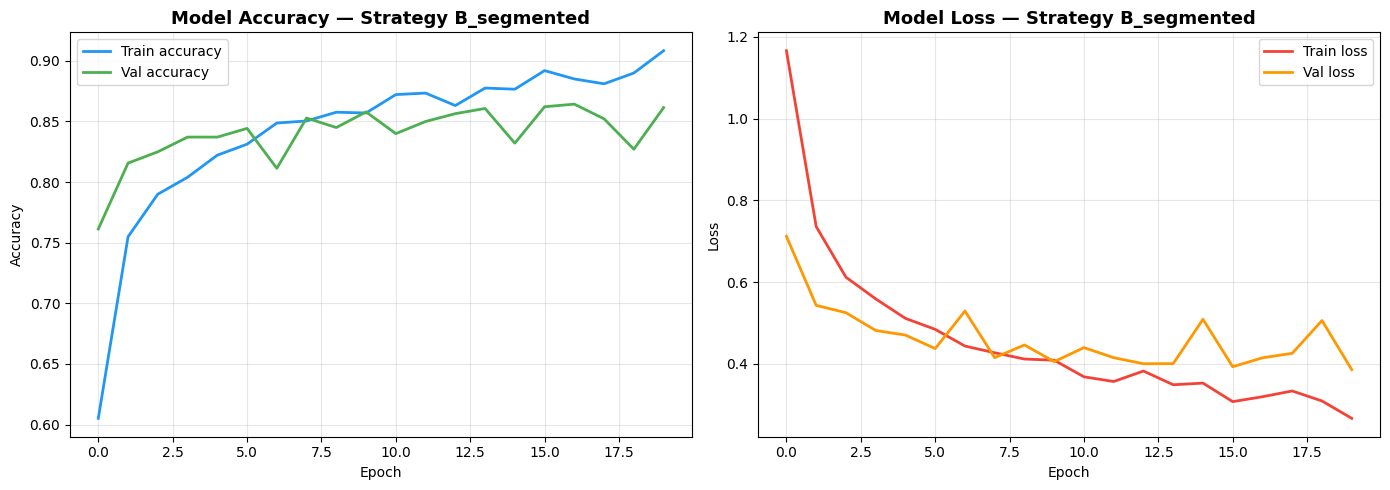


📊 Strategy B_segmented Final Results:
   Best Train Accuracy : 90.82%
   Best Val Accuracy   : 86.42%
   Final Train Loss    : 0.2670
   Final Val Loss      : 0.3861


In [7]:
#Cell 6 — Plot Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],
             label='Train accuracy', color='#2196F3', linewidth=2)
axes[0].plot(history.history['val_accuracy'],
             label='Val accuracy', color='#4CAF50', linewidth=2)
axes[0].set_title(f'Model Accuracy — Strategy {STRATEGY}',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],
             label='Train loss', color='#F44336', linewidth=2)
axes[1].plot(history.history['val_loss'],
             label='Val loss', color='#FF9800', linewidth=2)
axes[1].set_title(f'Model Loss — Strategy {STRATEGY}',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs("../outputs", exist_ok=True)
plt.savefig(f"../outputs/training_curves_{STRATEGY}.png",
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Strategy {STRATEGY} Final Results:")
print(f"   Best Train Accuracy : {max(history.history['accuracy']):.2%}")
print(f"   Best Val Accuracy   : {max(history.history['val_accuracy']):.2%}")
print(f"   Final Train Loss    : {history.history['loss'][-1]:.4f}")
print(f"   Final Val Loss      : {history.history['val_loss'][-1]:.4f}")

In [8]:
#Cell 7 — Evaluate on Test Set
print(f"🔄 Evaluating Strategy {STRATEGY} on test set...\n")

test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print(f"\n{'='*45}")
print(f"📊 Strategy {STRATEGY} — Test Results")
print(f"{'='*45}")
print(f"✅ Test Accuracy : {test_accuracy:.2%}")
print(f"📉 Test Loss     : {test_loss:.4f}")
print(f"{'='*45}")

# Direct comparison with Strategy A
print(f"\n📈 Strategy Comparison So Far:")
print(f"  Strategy A (Color only)     : 89.06%")
print(f"  Strategy B (Segmented only) : {test_accuracy:.2%}  ← new result")
print(f"\n  Difference: {(test_accuracy - 0.8906)*100:+.2f}%")

🔄 Evaluating Strategy B_segmented on test set...

44/44 ━━━━━━━━━━━━━━━━━━━━ 28s 648ms/step - accuracy: 0.8685 - loss: 0.3714

📊 Strategy B_segmented — Test Results
✅ Test Accuracy : 86.85%
📉 Test Loss     : 0.3714

📈 Strategy Comparison So Far:
  Strategy A (Color only)     : 89.06%
  Strategy B (Segmented only) : 86.85%  ← new result

  Difference: -2.21%


In [9]:
#Cell 8 — Save Model & Results
# Save final model
final_path = os.path.join(MODEL_PATH, f'model_{STRATEGY}_final.h5')
model.save(final_path)

# Save results to a text file for comparison later
results_path = r"D:\Development\8th Sem Project\TomatoClassification\outputs\results_summary.txt"
os.makedirs(os.path.dirname(results_path), exist_ok=True)

with open(results_path, 'a') as f:
    f.write(f"\nStrategy {STRATEGY}\n")
    f.write(f"  Test Accuracy : {test_accuracy:.4f}\n")
    f.write(f"  Test Loss     : {test_loss:.4f}\n")
    f.write(f"  Best Val Acc  : {max(history.history['val_accuracy']):.4f}\n")

print(f"✅ Model saved : {final_path}")
print(f"📝 Results logged to : {results_path}")
print(f"\n📁 Models folder now contains:")
for f in os.listdir(MODEL_PATH):
    size = os.path.getsize(os.path.join(MODEL_PATH, f)) / (1024*1024)
    print(f"   {f} — {size:.1f} MB")

✅ Model saved : D:\Development\8th Sem Project\TomatoClassification\models\model_B_segmented_final.h5
📝 Results logged to : D:\Development\8th Sem Project\TomatoClassification\outputs\results_summary.txt

📁 Models folder now contains:
   best_model.h5 — 11.0 MB
   best_model_B_segmented.h5 — 11.0 MB
   model_B_segmented_final.h5 — 11.0 MB
   tomato_classifier_final.h5 — 11.0 MB
